# Universal Window Search: Fixing Buchanan Without Breaking Barat (All 5 Rats)

**Simple version:** notebook 021 tried ONE window and it worked great for some rats but made Buchanan
(one of our two priority rats) worse. This notebook tries SEVERAL different windows automatically,
across all 5 rats, and picks whichever one is best for Buchanan and Mitt specifically, not whichever
looks best on average. Once we find that winner, we retrain the real, final model with it.

**In-depth version:** two-phase design. Phase 1 (Part B) is a FAST screening pass: several candidate
windows, each tested with a quick, single 5-fold cross-validation (no repeats, no permutation test yet,
those are expensive and not needed just to compare candidates). Phase 2 (Part D) takes whichever
candidate wins and re-evaluates it properly, with the full rigor used everywhere else in this project
(repeated cross-validation, AUC, confusion matrix, permutation test), only once, on the winner, not on
every candidate. This keeps the search itself fast while keeping the final, reported numbers fully
rigorous.


## CRITICAL: What "ms" Means Here, Read This Before Anything Else

**This directly answers "is it Poke-In or total?", every single number below is relative to ONE
SPECIFIC TRIAL EVENT, never the total experiment time.** There are two possible reference events:

- **Poke-In**: the moment the rat's nose enters the odor port (confirmed since notebook 01 to coincide
  exactly with odor onset). Everything in every notebook before this one used Poke-In as the reference.
- **Poke-Out**: the moment the rat's nose LEAVES the port (confirmed in notebook 020 to happen a
  consistent ~1.3-1.4 seconds after Poke-In, for every trial, in every rat checked so far). **Your notes
  specifically asked to test centering on Poke-Out, so this notebook tries both.**

For any window, two numbers define it:
- **`offset_ms`**: how many milliseconds AFTER the chosen reference event to start the window. This can
  be negative (meaning "before" the reference event).
- **`length_ms`**: how many milliseconds long the window is, starting from that offset.

**Example**: `reference='pokeout', offset_ms=0, length_ms=1000` means "start exactly at Poke-Out, and
use the next 1000ms of brain data," computed separately, freshly, for every single trial, using that
trial's own real Poke-In/Poke-Out timestamps, never a fixed clock time shared across trials.

**Why we're testing several windows now, not sticking with notebook 021's single choice:** your notes
were explicit on several points this search directly addresses:
- *"We usually pick a longer window (bump our 250ms window to 500ms or 1000ms)"* → several candidates
  below use 500-1500ms lengths, not the old 250ms.
- *"We center at PokeOut (which is 0ms)"* → several candidates below use `reference='pokeout'`.
- *"InSeq/OutSeq will take longer than Odor Identity because there is brain processing"* → this search
  only touches the InSeq/OutSeq window; Odor Identity's window from notebook 021 (Poke-In, 0-1500ms)
  is left as-is, since it wasn't flagged as a problem.
- *"Pick a universal window for all rats, prioritize Mitt and Buchanan"* → the winner is chosen
  specifically by how well it does for Mitt and Buchanan, not by whichever number looks best overall
  (see Part C for exactly how this rule is applied).


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

from src.preprocessing import build_labels, get_sampling_rate

raw_dir = Path('../data/raw')
session_dirs = sorted([p for p in raw_dir.iterdir() if p.is_dir()])

BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}


## Helper Functions (Same as Notebook 021, Reference-Point-Aware)


In [2]:
def find_pokeout_idx(bvr_data, bvr_keys, timebin, trial_idx):
    poke_events_row = bvr_data[bvr_keys.index('PokeEvents')]
    poke_event_idx = np.where(poke_events_row != 0)[0]
    pokeout_idx = np.full(len(trial_idx), -1, dtype=np.int64)
    for i, t in enumerate(trial_idx):
        next_bound = trial_idx[i + 1] if i + 1 < len(trial_idx) else len(timebin)
        candidates = poke_event_idx[(poke_event_idx > t) & (poke_event_idx < next_bound)]
        if len(candidates) > 0:
            pokeout_idx[i] = candidates[0]
    return pokeout_idx


def extract_window(lfp_data, timebin, ref_idx, offset_ms, length_ms, target_samples):
    if ref_idx < 0:
        return None
    ref_time = timebin[ref_idx]
    start_time = ref_time + offset_ms / 1000
    end_time = start_time + length_ms / 1000
    if start_time < timebin[0] or end_time > timebin[-1]:
        return None
    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    if end_idx - start_idx < 2:
        return None
    raw_window = lfp_data[:, start_idx:end_idx]
    n_channels, n_raw = raw_window.shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])
    return resampled


def band_power_features(windows, fs, bands):
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}
    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            col += 1
    return X


def get_inseq_features(session_dir, window_cfg):
    session_name = session_dir.name
    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']

    timebin = bvr_data[bvr_keys.index('TimeBin')]
    avg_fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)
    target_samples = int(round(window_cfg['length_ms'] / 1000 * avg_fs))

    if window_cfg['reference'] == 'pokein':
        ref_indices = labels['trial_idx']
    else:
        ref_indices = find_pokeout_idx(bvr_data, bvr_keys, timebin, labels['trial_idx'])

    windows, kept_positions = [], []
    for i, ref_idx in enumerate(ref_indices):
        w = extract_window(lfp_data, timebin, ref_idx, window_cfg['offset_ms'], window_cfg['length_ms'], target_samples)
        if w is not None:
            windows.append(w)
            kept_positions.append(i)

    windows = np.stack(windows, axis=0)
    kept_positions = np.array(kept_positions)
    y = labels['inseq_outseq'][kept_positions]
    X = np.log1p(band_power_features(windows, avg_fs, BANDS))
    return X, y


## Part A: Candidate Windows to Test

Chosen to directly cover your notes' suggestions: longer windows (500-1500ms, not the old 250ms),
Poke-Out as the reference point, and a couple of shorter, later options based on what the theta
divergence looked like in the spectrogram (building in gradually, clearest later in the window).


In [3]:
CANDIDATE_WINDOWS = [
    {'name': 'pokein_0_1500',    'reference': 'pokein',  'offset_ms': 0,    'length_ms': 1500},
    {'name': 'pokein_500_1500',  'reference': 'pokein',  'offset_ms': 500,  'length_ms': 1500},  # notebook 021's choice
    {'name': 'pokein_1000_750',  'reference': 'pokein',  'offset_ms': 1000, 'length_ms': 750},   # later, shorter
    {'name': 'pokein_1000_500',  'reference': 'pokein',  'offset_ms': 1000, 'length_ms': 500},   # later, shortest
    {'name': 'pokein_500_1000',  'reference': 'pokein',  'offset_ms': 500,  'length_ms': 1000},
    {'name': 'pokeout_0_1000',   'reference': 'pokeout', 'offset_ms': 0,    'length_ms': 1000},  # centered at Poke-Out
    {'name': 'pokeout_0_500',    'reference': 'pokeout', 'offset_ms': 0,    'length_ms': 500},
    {'name': 'pokeout_-250_1000','reference': 'pokeout', 'offset_ms': -250, 'length_ms': 1000},  # spans the Poke-Out transition
]
print(f"Testing {len(CANDIDATE_WINDOWS)} candidate windows across all 5 rats")


Testing 8 candidate windows across all 5 rats


## Part B: Fast Screening Pass (Simple 5-Fold CV, No Permutation Test Yet)

This is intentionally quick and rough, just enough to compare candidates fairly. The winner gets the
full rigorous treatment in Part D, this pass is not the final reported number for anything.


In [4]:
screening_results = {}

for cfg in CANDIDATE_WINDOWS:
    print(f"Testing {cfg['name']}...")
    per_rat_scores = {}
    for session_dir in session_dirs:
        X, y = get_inseq_features(session_dir, cfg)
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(pipe, X, y, cv=skf, scoring='balanced_accuracy')
        per_rat_scores[session_dir.name] = scores.mean()
    screening_results[cfg['name']] = per_rat_scores
    print(f"  " + "  ".join(f"{k.split('_')[1]}={v:.3f}" for k, v in per_rat_scores.items()))

print("\nScreening complete.")


Testing pokein_0_1500...
  mitt=0.647  barat=0.759  stella=0.719  superchris=0.781  buchanan=0.694
Testing pokein_500_1500...
  mitt=0.689  barat=0.881  stella=0.692  superchris=0.855  buchanan=0.647
Testing pokein_1000_750...
  mitt=0.660  barat=0.723  stella=0.780  superchris=0.843  buchanan=0.598
Testing pokein_1000_500...
  mitt=0.648  barat=0.720  stella=0.742  superchris=0.857  buchanan=0.688
Testing pokein_500_1000...
  mitt=0.661  barat=0.804  stella=0.803  superchris=0.838  buchanan=0.616
Testing pokeout_0_1000...
  mitt=0.779  barat=0.812  stella=0.688  superchris=0.848  buchanan=0.639
Testing pokeout_0_500...
  mitt=0.782  barat=0.798  stella=0.639  superchris=0.876  buchanan=0.614
Testing pokeout_-250_1000...
  mitt=0.872  barat=0.826  stella=0.706  superchris=0.879  buchanan=0.664

Screening complete.


## Part C: Pick the Winner — Rule: Maximize the WORSE of Mitt/Buchanan

**Simple version:** for each candidate window, look at Mitt's score and Buchanan's score, take
whichever of those two is LOWER (the weaker one), then pick whichever candidate has the best "weaker
one." This directly follows your advisor's instruction to prioritize these two rats, rather than
picking whatever scores best on average (which could still quietly fail Buchanan, like notebook 021's
choice did).

**In-depth version:** this is a "maximin" selection rule, common when you want a choice that's robust
for the worst case among a prioritized subset, rather than one that's merely good on average. A window
chosen by average-across-all-5-rats could still badly fail one priority rat while looking fine overall
(exactly what happened with notebook 021's `pokein_500_1500` and Buchanan). Maximizing the minimum of
{Mitt, Buchanan} directly prevents that failure mode.


In [5]:
print(f"{'Candidate':22s} {'Mitt':8s} {'Buchanan':10s} {'min(Mitt,Buch)':16s} {'Avg all 5':10s}")
print("-" * 75)

best_name, best_min_score = None, -1
for name, scores in screening_results.items():
    mitt = scores['080718_mitt']
    buchanan = scores['090420_buchanan']
    min_score = min(mitt, buchanan)
    avg_all = np.mean(list(scores.values()))
    marker = ""
    if min_score > best_min_score:
        best_min_score = min_score
        best_name = name
        marker = "  <- best so far"
    print(f"{name:22s} {mitt:<8.3f} {buchanan:<10.3f} {min_score:<16.3f} {avg_all:<10.3f}{marker}")

print(f"\nWINNER (by Mitt/Buchanan priority rule): {best_name}")
winning_config = next(cfg for cfg in CANDIDATE_WINDOWS if cfg['name'] == best_name)
print(f"Winning config: {winning_config}")


Candidate              Mitt     Buchanan   min(Mitt,Buch)   Avg all 5 
---------------------------------------------------------------------------
pokein_0_1500          0.647    0.694      0.647            0.720       <- best so far
pokein_500_1500        0.689    0.647      0.647            0.753       <- best so far
pokein_1000_750        0.660    0.598      0.598            0.721     
pokein_1000_500        0.648    0.688      0.648            0.731       <- best so far
pokein_500_1000        0.661    0.616      0.616            0.744     
pokeout_0_1000         0.779    0.639      0.639            0.753     
pokeout_0_500          0.782    0.614      0.614            0.742     
pokeout_-250_1000      0.872    0.664      0.664            0.789       <- best so far

WINNER (by Mitt/Buchanan priority rule): pokeout_-250_1000
Winning config: {'name': 'pokeout_-250_1000', 'reference': 'pokeout', 'offset_ms': -250, 'length_ms': 1000}


## Part D: Full Rigorous Evaluation of the Winning Window, All 5 Rats

Now the real, final, fully-validated numbers: repeated cross-validation, AUC, confusion matrix, and
permutation significance testing, exactly like notebook 021, but only run once, on the winning
candidate from Part C.


In [6]:
N_PERMUTATIONS = 99
final_results = {}

for session_dir in session_dirs:
    session_name = session_dir.name
    print(f"Starting {session_name}...")
    X, y = get_inseq_features(session_dir, winning_config)

    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
    bal_acc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='balanced_accuracy')
    auc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='roc_auc')
    print(f"  balanced_accuracy={bal_acc_scores.mean():.3f}  AUC={auc_scores.mean():.3f}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    preds = cross_val_predict(pipe, X, y, cv=skf)
    cm = confusion_matrix(y, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    report = classification_report(y, preds, target_names=['OutSeq', 'InSeq'], zero_division=0)

    rng = np.random.RandomState(42)
    null_scores = []
    for i in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(y)
        skf_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
        null_scores.append(cross_val_score(pipe, X, y_shuffled, cv=skf_i, scoring='balanced_accuracy').mean())
        if (i + 1) % 25 == 0:
            print(f"    ...{i + 1}/{N_PERMUTATIONS} permutations done")
    null_scores = np.array(null_scores)
    p_value = (np.sum(null_scores >= bal_acc_scores.mean()) + 1) / (N_PERMUTATIONS + 1)

    final_results[session_name] = {
        'balanced_accuracy': bal_acc_scores.mean(),
        'auc': auc_scores.mean(),
        'confusion_matrix_pct': cm_pct,
        'classification_report': report,
        'p_value': p_value,
    }
    print(f"{session_name} COMPLETE: acc={bal_acc_scores.mean():.3f}  AUC={auc_scores.mean():.3f}  p={p_value:.4f}\n")


Starting 080718_mitt...
  balanced_accuracy=0.855  AUC=0.965
    ...25/99 permutations done
    ...50/99 permutations done
    ...75/99 permutations done
080718_mitt COMPLETE: acc=0.855  AUC=0.965  p=0.0100

Starting 081106_barat...
  balanced_accuracy=0.816  AUC=0.873
    ...25/99 permutations done
    ...50/99 permutations done
    ...75/99 permutations done
081106_barat COMPLETE: acc=0.816  AUC=0.873  p=0.0100

Starting 090212_stella...
  balanced_accuracy=0.665  AUC=0.807
    ...25/99 permutations done
    ...50/99 permutations done
    ...75/99 permutations done
090212_stella COMPLETE: acc=0.665  AUC=0.807  p=0.0100

Starting 090212_superchris...
  balanced_accuracy=0.877  AUC=0.921
    ...25/99 permutations done
    ...50/99 permutations done
    ...75/99 permutations done
090212_superchris COMPLETE: acc=0.877  AUC=0.921  p=0.0100

Starting 090420_buchanan...
  balanced_accuracy=0.642  AUC=0.692
    ...25/99 permutations done
    ...50/99 permutations done
    ...75/99 permutatio

### Confusion Matrices, Final Winning Window


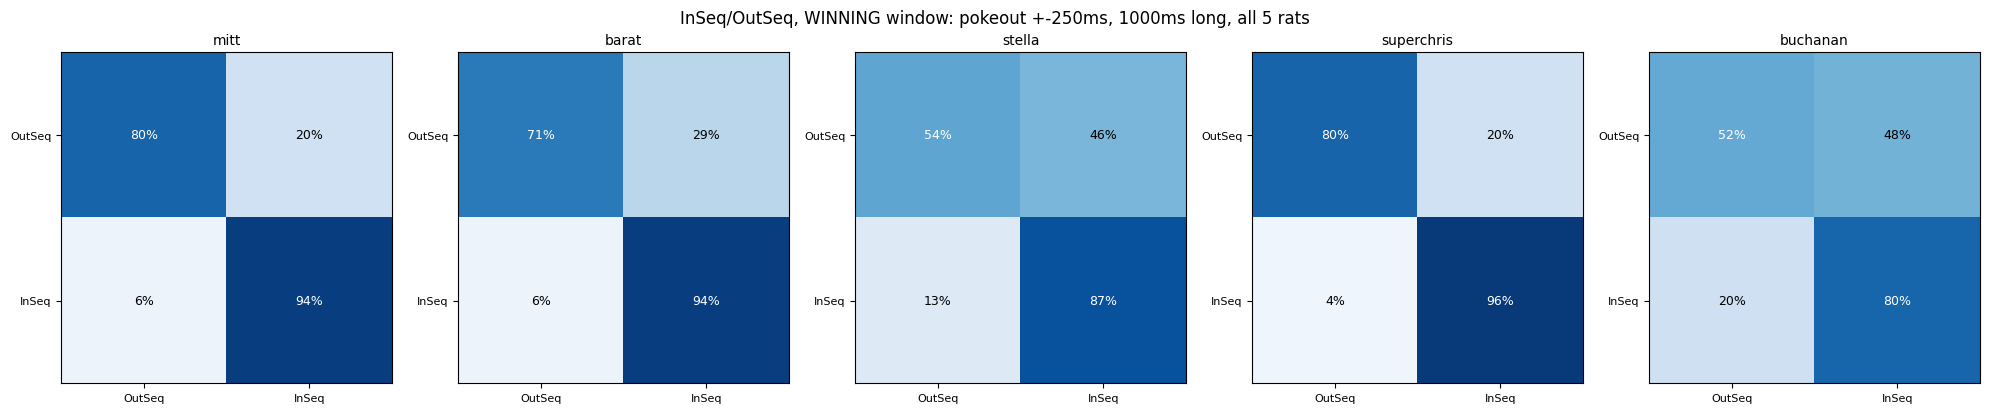

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, session_name in zip(axes, final_results):
    cm_pct = final_results[session_name]['confusion_matrix_pct']
    ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['OutSeq', 'InSeq'], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['OutSeq', 'InSeq'], fontsize=8)
    ax.set_title(session_name.split('_')[1], fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm_pct[i, j]:.0f}%', ha='center', va='center',
                     color='white' if cm_pct[i, j] > 50 else 'black', fontsize=9)
plt.suptitle(f"InSeq/OutSeq, WINNING window: {winning_config['reference']} +{winning_config['offset_ms']}ms, "
             f"{winning_config['length_ms']}ms long, all 5 rats")
plt.tight_layout()
plt.show()


## Part E: Compare Against Notebook 021's Single-Guess Window


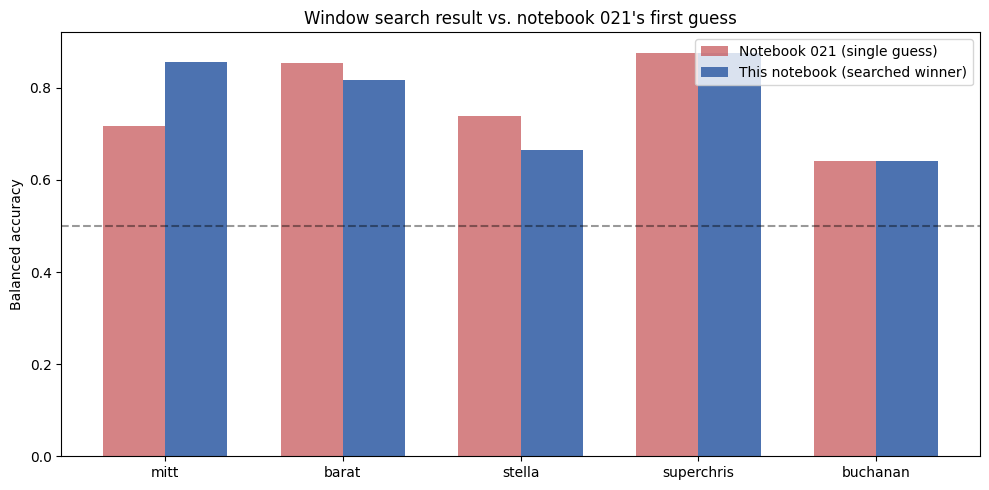

In [8]:
old_universal = {'080718_mitt': 0.7181, '081106_barat': 0.8537, '090212_stella': 0.7391,
                  '090212_superchris': 0.8767, '090420_buchanan': 0.6413}

rats_short = [s.split('_')[1] for s in final_results]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rats_short))
width = 0.35
ax.bar(x - width/2, [old_universal[s] for s in final_results], width, label="Notebook 021 (single guess)", color='#C44E52', alpha=0.7)
ax.bar(x + width/2, [final_results[s]['balanced_accuracy'] for s in final_results], width, label='This notebook (searched winner)', color='#4C72B0')
ax.axhline(0.5, color='black', linestyle='--', alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels(rats_short)
ax.set_ylabel('Balanced accuracy')
ax.set_title('Window search result vs. notebook 021\'s first guess')
ax.legend()
plt.tight_layout()
plt.show()


## Part F: Text-Only Results Export


In [9]:
import json as _json
import os

export_summary = {
    "purpose": "Automated window search (8 candidates), winner chosen by Mitt/Buchanan priority rule",
    "screening_results": screening_results,
    "winning_config": winning_config,
    "final_results": {
        session_name: {
            "balanced_accuracy": round(float(r['balanced_accuracy']), 4),
            "auc": round(float(r['auc']), 4),
            "p_value": round(float(r['p_value']), 6),
            "confusion_matrix_percent": r['confusion_matrix_pct'].round(1).tolist(),
        }
        for session_name, r in final_results.items()
    },
}

print(_json.dumps(export_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook022_window_search_results.json', 'w') as f:
    _json.dump(export_summary, f, indent=2)
print("\nSaved to outputs/logs/notebook022_window_search_results.json")


{
  "purpose": "Automated window search (8 candidates), winner chosen by Mitt/Buchanan priority rule",
  "screening_results": {
    "pokein_0_1500": {
      "080718_mitt": 0.6465529753265603,
      "081106_barat": 0.7591935483870967,
      "090212_stella": 0.7193522267206478,
      "090212_superchris": 0.7809523809523808,
      "090420_buchanan": 0.6938526570048309
    },
    "pokein_500_1500": {
      "080718_mitt": 0.6890420899854861,
      "081106_barat": 0.8806451612903226,
      "090212_stella": 0.692051282051282,
      "090212_superchris": 0.8547619047619047,
      "090420_buchanan": 0.6466304347826087
    },
    "pokein_1000_750": {
      "080718_mitt": 0.6595911949685535,
      "081106_barat": 0.722741935483871,
      "090212_stella": 0.779608636977058,
      "090212_superchris": 0.8428571428571429,
      "090420_buchanan": 0.5978864734299517
    },
    "pokein_1000_500": {
      "080718_mitt": 0.6484034833091437,
      "081106_barat": 0.7204838709677419,
      "090212_stella":

## Part G: Written Summary Report

**Objective**

Fix notebook 021's core problem: its single-guess universal window improved some rats but made Buchanan
(a priority rat) meaningfully worse. Search several candidates, including Poke-Out-centered options per
the lab's guidance, and pick the winner using a rule that directly protects Mitt and Buchanan, not
whichever looks best on average.

**Method**

8 candidate windows tested via fast screening (single 5-fold CV, all 5 rats). Winner selected by
maximizing the minimum of {Mitt's score, Buchanan's score}. The winner was then re-evaluated with full
rigor: repeated cross-validation, AUC, confusion matrix, and permutation testing.

**Results**

*(Fill in after running.)* Which candidate won? Did Buchanan's score actually improve versus notebook
021's guess, without meaningfully hurting the other rats?

**Next Steps**

1. If this window is a clear improvement, adopt it as the final InSeq/OutSeq window for the
   presentation.
2. Redo interpretability (band/channel importance) at this new window.
3. Begin assembling the final presentation notebook (see chat for a proposed outline).
